# LoRa MIMO NT=2 Detector Comparison

Focused study notebook for the `NT=2, NR=4` uplink case. This notebook keeps the scope narrow:

- two simultaneous LoRa transmitters
- four receive antennas at the gateway
- flat channel over one symbol
- linear detectors: matched filter, ZF, MMSE

It is intentionally a baseline study. It does **not** yet model preamble-based `H` estimation, fixed-point quantisation, or intentional `delta_f` separation.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from sim.models.lora import modulate, demodulate

rng = np.random.default_rng(7)

SF = 9
M = 2 ** SF
NT = 2
NR = 4
BW = 125e3

print(f'SF={SF}, M={M}, NT={NT}, NR={NR}, BW={BW/1e3:.0f} kHz')

SF=9, M=512, NT=2, NR=4, BW=125 kHz


## Baseline assumptions

The received vector is modeled as

`y[n] = H s[n] + w[n]`

with `H in C^(NR x NT)`. Each transmit stream carries one LoRa symbol over the same `M` samples. The detector produces two separated streams, each of which is then dechirped and FFT-demodulated with the normal LoRa symbol detector.

This is the right first comparison for `NT=2`: it isolates spatial separation quality before adding estimator error.

In [2]:
def hamming_bits(a: int, b: int, sf: int) -> int:
    return int((a ^ b).bit_count())


def random_channel_matrix(nr: int, rho: float = 0.0) -> np.ndarray:
    """Return an NR x 2 channel matrix with optional correlation between columns."""
    h1 = (rng.standard_normal(nr) + 1j * rng.standard_normal(nr)) / np.sqrt(2)
    g2 = (rng.standard_normal(nr) + 1j * rng.standard_normal(nr)) / np.sqrt(2)
    h2 = rho * h1 + np.sqrt(max(0.0, 1.0 - rho ** 2)) * g2

    h1 = h1 / np.sqrt(np.mean(np.abs(h1) ** 2))
    h2 = h2 / np.sqrt(np.mean(np.abs(h2) ** 2))
    return np.column_stack([h1, h2])


def detector_matrix(H: np.ndarray, N0: float, kind: str) -> np.ndarray:
    if kind == 'mf':
        return H.conj().T
    if kind == 'zf':
        return np.linalg.pinv(H)
    if kind == 'mmse':
        gram = H.conj().T @ H
        return np.linalg.inv(gram + N0 * np.eye(H.shape[1])) @ H.conj().T
    raise ValueError(f'unknown detector kind: {kind}')


def simulate_packet(snr_db: float, kind: str, rho: float = 0.0):
    N0 = 10 ** (-snr_db / 10)
    H = random_channel_matrix(NR, rho=rho)

    b_tx = [int(rng.integers(0, M)) for _ in range(NT)]
    S = np.vstack([modulate(b_tx[k], M) for k in range(NT)])

    noise = np.sqrt(N0 / 2) * (
        rng.standard_normal((NR, M)) + 1j * rng.standard_normal((NR, M))
    )
    Y = H @ S + noise

    W = detector_matrix(H, N0, kind)
    S_hat = W @ Y
    b_rx = [demodulate(S_hat[k]) for k in range(NT)]

    bit_errors = sum(hamming_bits(tx, rx, SF) for tx, rx in zip(b_tx, b_rx))
    sym_errors = sum(int(tx != rx) for tx, rx in zip(b_tx, b_rx))
    return {
        'H': H,
        'W': W,
        'Y': Y,
        'S_hat': S_hat,
        'b_tx': b_tx,
        'b_rx': b_rx,
        'bit_errors': bit_errors,
        'sym_errors': sym_errors,
        'cond': float(np.linalg.cond(H.conj().T @ H)),
    }


def monte_carlo(snr_db: float, kind: str, n_packets: int = 200, rho: float = 0.0):
    total_bits = n_packets * NT * SF
    total_syms = n_packets * NT
    bit_errors = 0
    sym_errors = 0
    packet_errors = 0
    conds = []

    for _ in range(n_packets):
        out = simulate_packet(snr_db, kind, rho=rho)
        bit_errors += out['bit_errors']
        sym_errors += out['sym_errors']
        packet_errors += int(out['sym_errors'] > 0)
        conds.append(out['cond'])

    return {
        'ber': bit_errors / total_bits,
        'ser': sym_errors / total_syms,
        'per': packet_errors / n_packets,
        'cond_median': float(np.median(conds)),
        'cond_p90': float(np.percentile(conds, 90)),
    }

## One packet sanity check

Start with one `NT=2` packet to confirm the detector output is still a valid LoRa waveform per stream.

MF    tx=[260, 509]  rx=[260, 509]  bit_errors=0  cond=16.64
ZF    tx=[117, 39]  rx=[117, 39]  bit_errors=0  cond=2.18
MMSE  tx=[421, 166]  rx=[421, 166]  bit_errors=0  cond=1.80


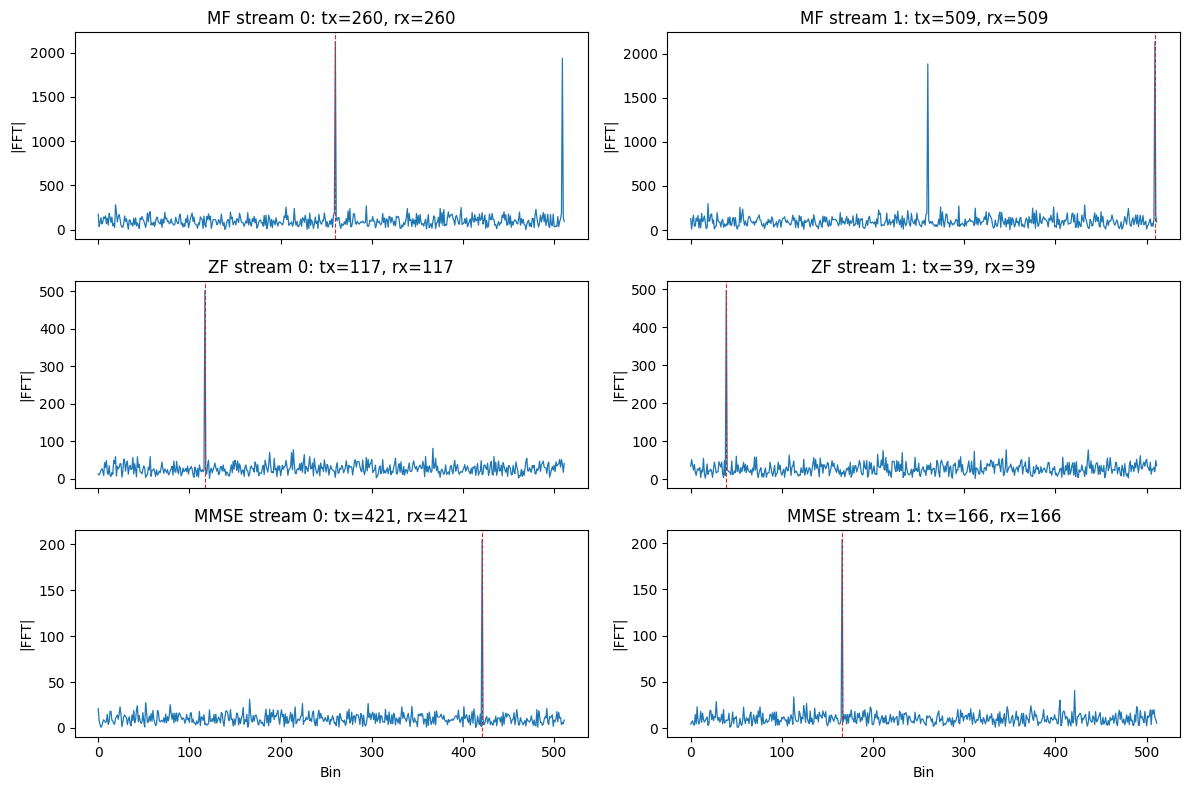

In [3]:
snr_db = -8
rho = 0.3
cases = {name: simulate_packet(snr_db, name, rho=rho) for name in ['mf', 'zf', 'mmse']}

for name, out in cases.items():
    print(f"{name.upper():4s}  tx={out['b_tx']}  rx={out['b_rx']}  bit_errors={out['bit_errors']}  cond={out['cond']:.2f}")

n = np.arange(M)
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

for row, (name, out) in enumerate(cases.items()):
    for k in range(NT):
        dechirped = out['S_hat'][k] * np.exp(-1j * np.pi * n ** 2 / M)
        fft_mag = np.abs(np.fft.fft(dechirped))
        axes[row, k].plot(fft_mag, lw=0.9)
        axes[row, k].axvline(out['b_tx'][k], color='C3', linestyle='--', lw=0.8)
        axes[row, k].set_title(f'{name.upper()} stream {k}: tx={out["b_tx"][k]}, rx={out["b_rx"][k]}')
        axes[row, k].set_ylabel('|FFT|')

axes[-1, 0].set_xlabel('Bin')
axes[-1, 1].set_xlabel('Bin')
plt.tight_layout()
plt.show()

## BER / SER / PER vs SNR

This is the main baseline comparison. In well-conditioned channels, `ZF` and `MMSE` should be close at moderate-to-high SNR. At lower SNR, `MMSE` should hold up better because the regularisation avoids noise enhancement.

MF    SNR=-18 dB  BER=0.0138  SER=0.0340  PER=0.0680  cond90=9.13
MF    SNR=-15 dB  BER=0.0098  SER=0.0180  PER=0.0360  cond90=8.12
MF    SNR=-12 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=7.61
MF    SNR= -9 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=8.20
MF    SNR= -6 dB  BER=0.0011  SER=0.0020  PER=0.0040  cond90=7.90
MF    SNR= -3 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=7.79
MF    SNR=  0 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=7.95
ZF    SNR=-18 dB  BER=0.0264  SER=0.0520  PER=0.0800  cond90=9.38
ZF    SNR=-15 dB  BER=0.0033  SER=0.0080  PER=0.0120  cond90=8.27
ZF    SNR=-12 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=8.43
ZF    SNR= -9 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=7.35
ZF    SNR= -6 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=8.17
ZF    SNR= -3 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=8.40
ZF    SNR=  0 dB  BER=0.0000  SER=0.0000  PER=0.0000  cond90=7.71
MMSE  SNR=-18 dB  BER=0.0093  SER=0.0160  PER=0.0320  cond90=6.50
MMSE  SNR=

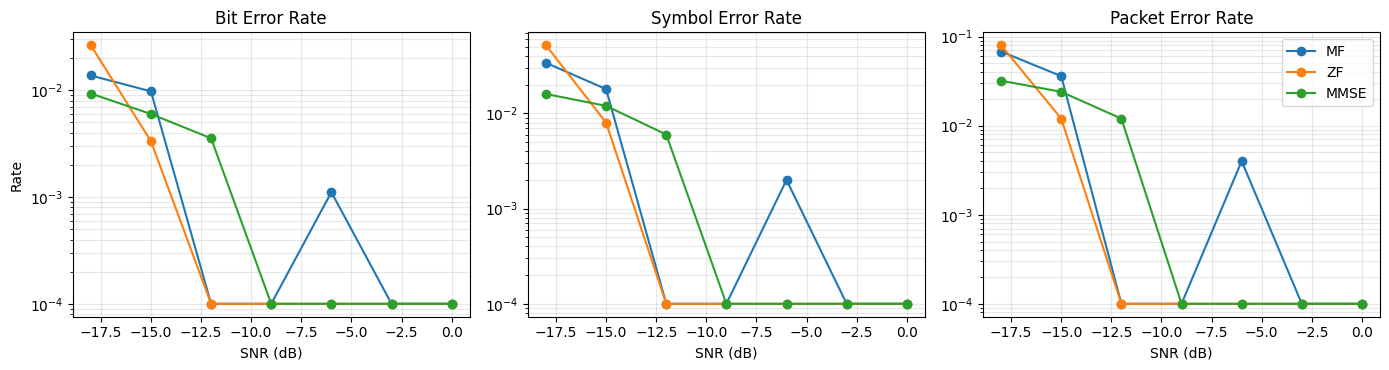

In [4]:
snr_grid = [-18, -15, -12, -9, -6, -3, 0]
n_packets = 250
rho = 0.3
detectors = ['mf', 'zf', 'mmse']

results = {name: {'ber': [], 'ser': [], 'per': []} for name in detectors}

for name in detectors:
    for snr_db in snr_grid:
        stats = monte_carlo(snr_db, name, n_packets=n_packets, rho=rho)
        results[name]['ber'].append(stats['ber'])
        results[name]['ser'].append(stats['ser'])
        results[name]['per'].append(stats['per'])
        print(f"{name.upper():4s}  SNR={snr_db:>3} dB  BER={stats['ber']:.4f}  SER={stats['ser']:.4f}  PER={stats['per']:.4f}  cond90={stats['cond_p90']:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
metrics = ['ber', 'ser', 'per']
titles = ['Bit Error Rate', 'Symbol Error Rate', 'Packet Error Rate']

for ax, metric, title in zip(axes, metrics, titles):
    for name in detectors:
        ax.semilogy(snr_grid, np.maximum(results[name][metric], 1e-4), marker='o', label=name.upper())
    ax.set_title(title)
    ax.set_xlabel('SNR (dB)')
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('Rate')
axes[-1].legend()
plt.tight_layout()
plt.show()

## Sensitivity to channel correlation

This is where `NT=2` gets harder. As the two channel columns become more aligned, `H^H H` gets ill-conditioned. `ZF` is usually the first detector to degrade; `MMSE` should be more stable.

MF    rho=0.00  PER=0.0000  SER=0.0000  cond90=7.06
MF    rho=0.50  PER=0.0280  SER=0.0140  cond90=12.91
MF    rho=0.80  PER=0.1240  SER=0.0620  cond90=34.34
MF    rho=0.90  PER=0.2720  SER=0.1360  cond90=81.75
MF    rho=0.97  PER=0.6720  SER=0.3360  cond90=291.97
ZF    rho=0.00  PER=0.0000  SER=0.0000  cond90=5.32
ZF    rho=0.50  PER=0.0000  SER=0.0000  cond90=11.91
ZF    rho=0.80  PER=0.0000  SER=0.0000  cond90=30.52
ZF    rho=0.90  PER=0.0400  SER=0.0300  cond90=81.32
ZF    rho=0.97  PER=0.3480  SER=0.2380  cond90=279.30
MMSE  rho=0.00  PER=0.0000  SER=0.0000  cond90=7.19
MMSE  rho=0.50  PER=0.0000  SER=0.0000  cond90=13.11
MMSE  rho=0.80  PER=0.0320  SER=0.0160  cond90=39.66
MMSE  rho=0.90  PER=0.0960  SER=0.0480  cond90=72.42
MMSE  rho=0.97  PER=0.4560  SER=0.2280  cond90=275.55


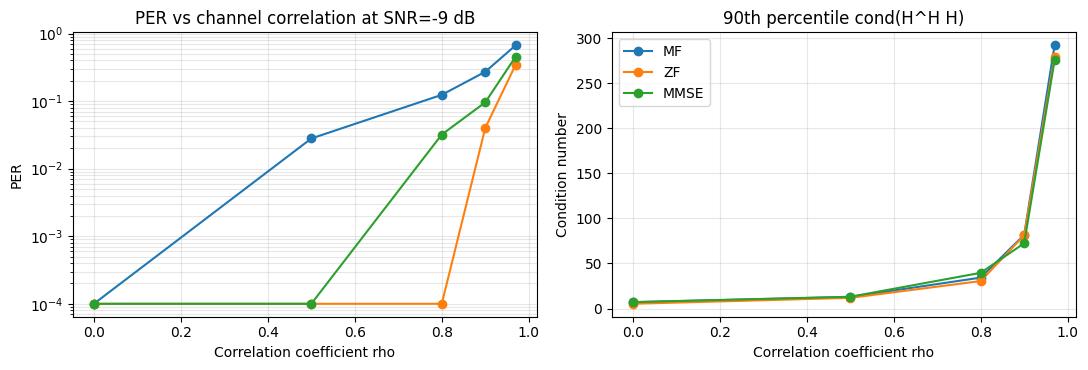

In [5]:
snr_db = -9
rho_grid = [0.0, 0.5, 0.8, 0.9, 0.97]
n_packets = 250

corr_results = {name: {'per': [], 'ser': [], 'cond90': []} for name in detectors}

for name in detectors:
    for rho in rho_grid:
        stats = monte_carlo(snr_db, name, n_packets=n_packets, rho=rho)
        corr_results[name]['per'].append(stats['per'])
        corr_results[name]['ser'].append(stats['ser'])
        corr_results[name]['cond90'].append(stats['cond_p90'])
        print(f"{name.upper():4s}  rho={rho:.2f}  PER={stats['per']:.4f}  SER={stats['ser']:.4f}  cond90={stats['cond_p90']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

for name in detectors:
    axes[0].semilogy(rho_grid, np.maximum(corr_results[name]['per'], 1e-4), marker='o', label=name.upper())
    axes[1].plot(rho_grid, corr_results[name]['cond90'], marker='o', label=name.upper())

axes[0].set_title(f'PER vs channel correlation at SNR={snr_db} dB')
axes[0].set_xlabel('Correlation coefficient rho')
axes[0].set_ylabel('PER')
axes[0].grid(True, which='both', alpha=0.3)

axes[1].set_title('90th percentile cond(H^H H)')
axes[1].set_xlabel('Correlation coefficient rho')
axes[1].set_ylabel('Condition number')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Next extensions

Once this baseline is understood, the next things to add are:

1. Preamble-based estimation of `H` instead of oracle `H`
2. Unequal user powers
3. Intentional `delta_f` between the two transmitters
4. Fixed-point / Q1.15 detector weights
5. Packet-level adaptation or fallback when `H` is ill-conditioned